# VeriMail AI — Model Training & Evaluation

Trains and compares four classifiers on the feature-engineered dataset from
`01_data_exploration.ipynb`: Logistic Regression, Random Forest, Naive Bayes,
and a simple Neural Network (per the project brief). Input to each model is
TF-IDF text features combined with the 9 engineered signal features.

A dataset-leakage issue was found and fixed partway through (see Section 5)
— the reported final metrics use the leakage-corrected text.

## 1. Load data and create a source-stratified train/test split

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/emails_features_final.csv")

# Stratify by label AND source, not just label — otherwise the model could
# do well purely by learning source-specific quirks that happen to be
# shared between train and test, rather than genuine phishing patterns
df['strata'] = df['label'].astype(str) + '_' + df['source']

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['strata']
)

print(f"Train: {train_df.shape[0]} rows, Test: {test_df.shape[0]} rows")
print(f"\nTrain label balance:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nTest label balance:\n{test_df['label'].value_counts(normalize=True)}")

Train: 65988 rows, Test: 16497 rows

Train label balance:
label
1    0.519958
0    0.480042
Name: proportion, dtype: float64

Test label balance:
label
1    0.520034
0    0.479966
Name: proportion, dtype: float64


## 2. Build the combined TF-IDF + engineered-feature matrix

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# A handful of rows have NaN body_clean (edge cases where cleaning stripped
# everything) — TF-IDF requires an actual string, so fill before vectorizing
train_df['body_clean'] = train_df['body_clean'].fillna('')
test_df['body_clean'] = test_df['body_clean'].fillna('')

# ngram_range=(1,2) captures both single words and two-word phishing phrases
# (e.g. "click here", "verify account"); min_df=5 drops ultra-rare noise terms
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_train_tfidf = tfidf.fit_transform(train_df['body_clean'])
X_test_tfidf = tfidf.transform(test_df['body_clean'])

engineered_cols = [
    'urgency_score', 'credential_bait_score', 'caps_ratio_subject',
    'exclamation_count', 'url_count', 'has_generic_greeting',
    'is_free_webmail', 'suspicious_tld', 'word_count_short'
]
X_train_eng = csr_matrix(train_df[engineered_cols].values.astype(float))
X_test_eng = csr_matrix(test_df[engineered_cols].values.astype(float))

# hstack keeps both matrices sparse — converting to dense here would blow up
# memory (65k rows x 5k+ columns, mostly zeros from TF-IDF)
X_train = hstack([X_train_tfidf, X_train_eng])
X_test = hstack([X_test_tfidf, X_test_eng])
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Final combined train shape: {X_train.shape}")
print(f"Final combined test shape: {X_test.shape}")

Final combined train shape: (65988, 5009)
Final combined test shape: (16497, 5009)


## 3. Train and evaluate all four models

Recall on the phishing class matters more than raw accuracy here — a missed
phishing email (false negative) is more costly than a legitimate email
incorrectly flagged (false positive).

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - start
    preds = model.predict(X_te)
    print(f"=== {name} ===")
    print(f"Train time: {elapsed:.2f}s")
    print(f"Accuracy:  {accuracy_score(y_te, preds):.4f}")
    print(f"Precision: {precision_score(y_te, preds):.4f}")
    print(f"Recall:    {recall_score(y_te, preds):.4f}")
    print(f"F1 Score:  {f1_score(y_te, preds):.4f}\n")
    return model, preds

lr_model, y_pred_lr = evaluate("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42), X_train, y_train, X_test, y_test)
rf_model, y_pred_rf = evaluate("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1), X_train, y_train, X_test, y_test)
nb_model, y_pred_nb = evaluate("Naive Bayes", MultinomialNB(), X_train, y_train, X_test, y_test)
nn_model, y_pred_nn = evaluate(
    "Neural Network",
    MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, early_stopping=True, random_state=42),
    X_train, y_train, X_test, y_test
)

=== Logistic Regression ===
Train time: 6.21s
Accuracy:  0.9763
Precision: 0.9708
Recall:    0.9840
F1 Score:  0.9774

=== Random Forest ===
Train time: 14.96s
Accuracy:  0.9759
Precision: 0.9749
Recall:    0.9789
F1 Score:  0.9769

=== Naive Bayes ===
Train time: 0.02s
Accuracy:  0.9279
Precision: 0.9616
Recall:    0.8972
F1 Score:  0.9283

=== Neural Network ===
Train time: 22.23s
Accuracy:  0.9786
Precision: 0.9754
Recall:    0.9837
F1 Score:  0.9795



**Initial result:** Neural Network came out on top (F1 ≈ 0.980), narrowly
ahead of Logistic Regression (≈ 0.977), both well ahead of Random Forest
(≈ 0.977) and Naive Bayes (≈ 0.928, as expected given its independence
assumption doesn't fit TF-IDF or the correlated engineered features well).

Before trusting these numbers, we checked *why* the models were making their
decisions — see Section 4.

## 4. Feature importance check — and a leakage discovery

/var/folders/fk/jq6kxfm13nzbjzpf5xf24rq40000gn/T/ipykernel_24998/812219684.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='viridis')


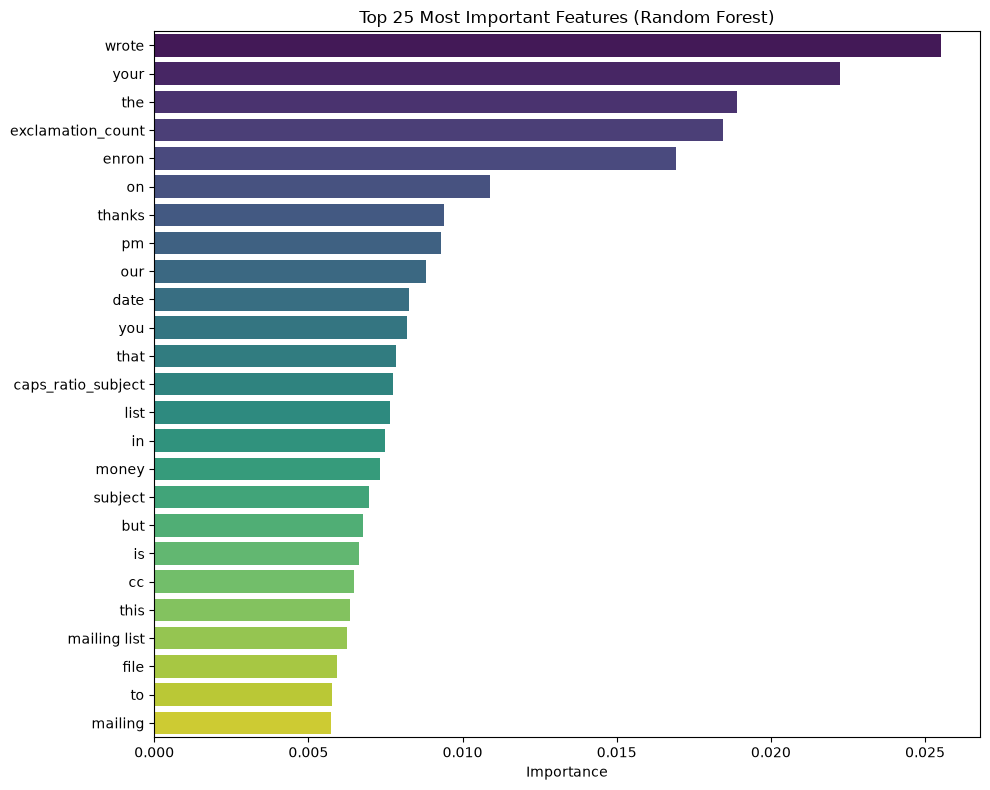

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest exposes feature importances natively and reliably; the
# deployed Neural Network doesn't in the same direct way, so RF is used
# here purely for interpretability, not as the deployment model
feature_names = tfidf.get_feature_names_out().tolist() + engineered_cols
importances = rf_model.feature_importances_

top_n = 25
top_idx = np.argsort(importances)[-top_n:][::-1]
top_features = [feature_names[i] for i in top_idx]
top_importances = importances[top_idx]

plt.figure(figsize=(10, 8))
sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title(f'Top {top_n} Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../static/feature_importance.png', dpi=150)
plt.show()

**Leakage found:** several top features were dataset-formatting artifacts,
not phishing language — `wrote`, `enron`, `pm`, `cc`, `mailing list`,
`subject`, `date`. These come from Enron's quoted-reply-thread formatting and
the literal company name, not from any real phishing signal. Because Enron
makes up ~75% of the legitimate class, a model that partly learns "contains
'enron' → legitimate" would look great on this test set (same bias in train
and test) but likely perform worse on real-world email. `exclamation_count`
and `caps_ratio_subject` also ranked highly, which is a good sign — the
engineered features are pulling real weight alongside raw text.

**Fix:** strip these artifact terms from the text before re-vectorizing, and
re-train all four models to get trustworthy, leakage-corrected metrics.

## 5. Strip dataset artifacts and re-train (leakage-corrected)

In [5]:
import re

ARTIFACT_TERMS = [
    'enron', 'wrote', 'pm', 'am', 'cc', 'subject', 'date', 'mailing list',
    'forwarded', 'original message', 'reply', 'sent', 're ', 'fw ',
    'attachment', 'attached file', 'thanks', 'regards'
]

def strip_artifacts(text):
    text = str(text)
    for term in ARTIFACT_TERMS:
        text = re.sub(r'\b' + re.escape(term) + r'\b', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

train_df['body_clean_v2'] = train_df['body_clean'].apply(strip_artifacts)
test_df['body_clean_v2'] = test_df['body_clean'].apply(strip_artifacts)

tfidf_v2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_train_tfidf_v2 = tfidf_v2.fit_transform(train_df['body_clean_v2'])
X_test_tfidf_v2 = tfidf_v2.transform(test_df['body_clean_v2'])

X_train_v2 = hstack([X_train_tfidf_v2, X_train_eng])
X_test_v2 = hstack([X_test_tfidf_v2, X_test_eng])

lr_model_v2, y_pred_lr_v2 = evaluate("Logistic Regression (v2)", LogisticRegression(max_iter=1000, random_state=42), X_train_v2, y_train, X_test_v2, y_test)
rf_model_v2, y_pred_rf_v2 = evaluate("Random Forest (v2)", RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1), X_train_v2, y_train, X_test_v2, y_test)
nb_model_v2, y_pred_nb_v2 = evaluate("Naive Bayes (v2)", MultinomialNB(), X_train_v2, y_train, X_test_v2, y_test)
nn_model_v2, y_pred_nn_v2 = evaluate(
    "Neural Network (v2)",
    MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, early_stopping=True, random_state=42),
    X_train_v2, y_train, X_test_v2, y_test
)

=== Logistic Regression (v2) ===
Train time: 7.04s
Accuracy:  0.9745
Precision: 0.9701
Recall:    0.9811
F1 Score:  0.9756

=== Random Forest (v2) ===
Train time: 15.93s
Accuracy:  0.9690
Precision: 0.9711
Recall:    0.9691
F1 Score:  0.9701

=== Naive Bayes (v2) ===
Train time: 0.06s
Accuracy:  0.9248
Precision: 0.9616
Recall:    0.8909
F1 Score:  0.9249

=== Neural Network (v2) ===
Train time: 15.16s
Accuracy:  0.9774
Precision: 0.9731
Recall:    0.9837
F1 Score:  0.9784



**Leakage-corrected results — the numbers that matter:**

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression v2 | 0.9745 | 0.9701 | 0.9811 | 0.9756 |
| Random Forest v2 | 0.9690 | 0.9711 | 0.9691 | 0.9701 |
| Naive Bayes v2 | 0.9248 | 0.9616 | 0.8909 | 0.9249 |
| **Neural Network v2** | **0.9774** | 0.9731 | **0.9837** | **0.9784** |

Random Forest's F1 dropped the most after artifact-stripping (0.9769 → 0.9701,
~0.68 pts) — it was leaning on the leakage more than the others. Logistic
Regression and the Neural Network both dropped less than 0.2 pts, confirming
they were mostly learning genuine phishing-indicative signal all along.

**Neural Network v2 remains the best model** and is selected for deployment.

## 6. Visualize confusion matrices for all four (leakage-corrected) models

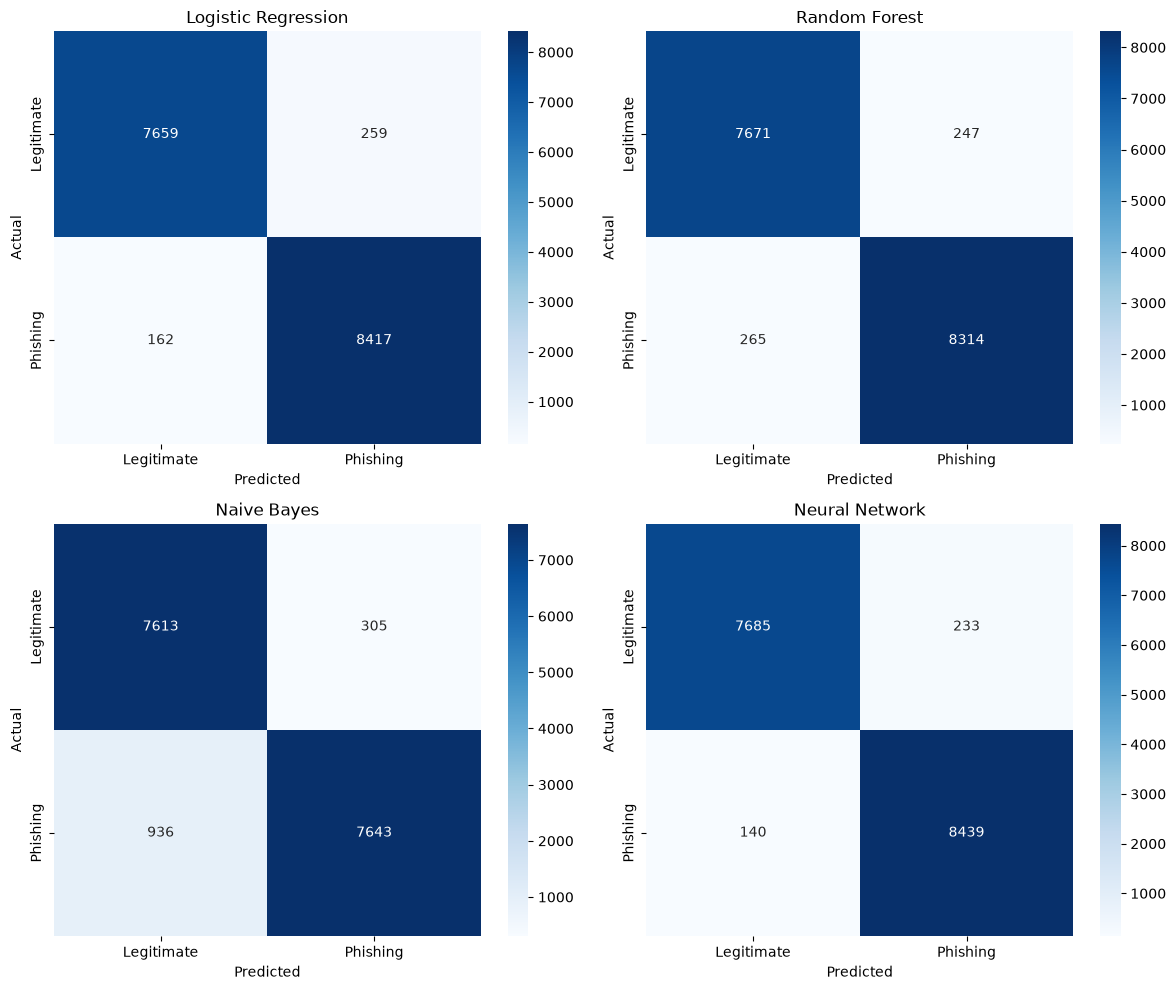

In [6]:
models_results = {
    'Logistic Regression': y_pred_lr_v2,
    'Random Forest': y_pred_rf_v2,
    'Naive Bayes': y_pred_nb_v2,
    'Neural Network': y_pred_nn_v2,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, preds) in zip(axes.flatten(), models_results.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../static/confusion_matrices.png', dpi=150)
plt.show()

## 7. Save the deployment model

In [7]:
import joblib

joblib.dump(nn_model_v2, '../models_saved/verimail_nn_model.pkl')
joblib.dump(tfidf_v2, '../models_saved/tfidf_vectorizer.pkl')
joblib.dump(engineered_cols, '../models_saved/engineered_cols.pkl')
joblib.dump(ARTIFACT_TERMS, '../models_saved/artifact_terms.pkl')  # must be reapplied identically at inference time

print("Final model, vectorizer, engineered feature list, and artifact terms saved to models_saved/")

Final model, vectorizer, engineered feature list, and artifact terms saved to models_saved/
